In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [17]:
data = pd.read_csv("loan_data.csv")
print("Dataset Shape :",data.shape)
data.head()

Dataset Shape : (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [18]:
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1


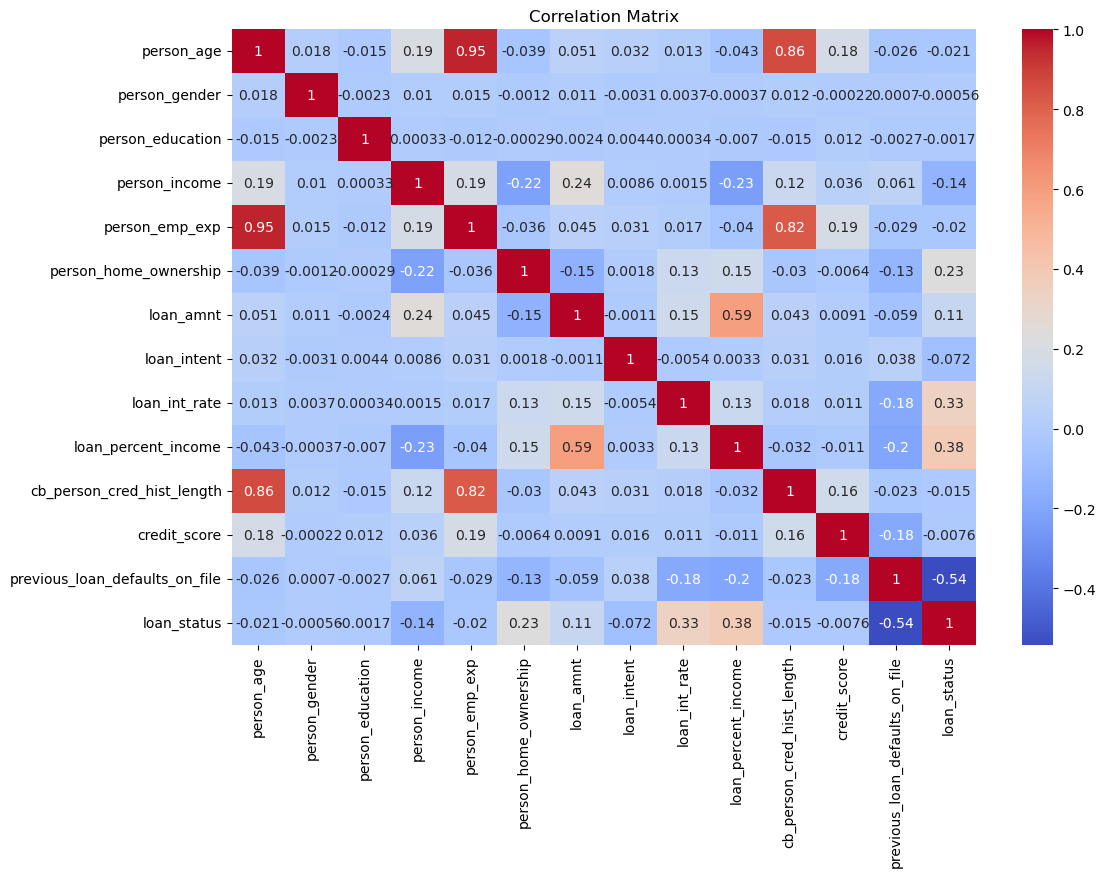

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
data.drop(columns = ['person_emp_exp'], inplace=True)
data

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,6,604,0,1


In [23]:
data.drop(columns = ['cb_person_cred_hist_length'], inplace=True)

In [24]:
data

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,604,0,1


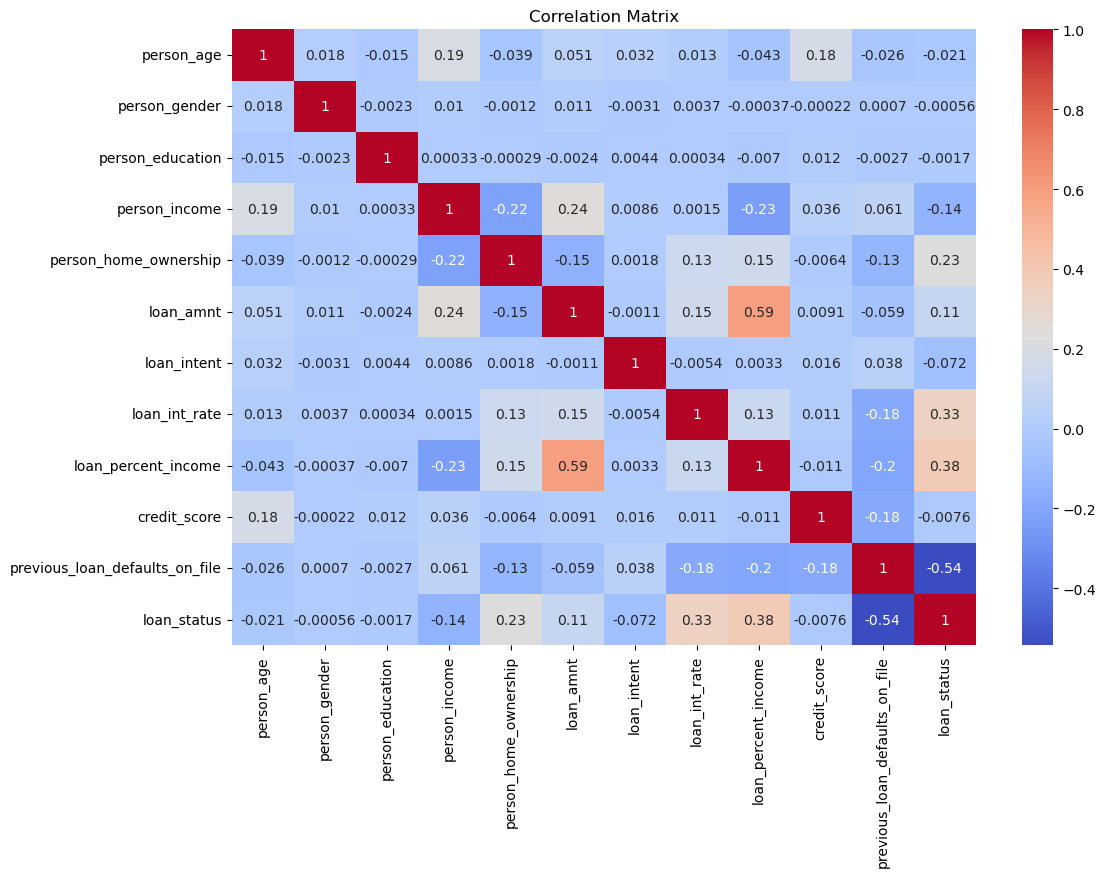

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
rbf_model = SVC( kernel='rbf',C=1.0,gamma='scale')
rbf_model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
rbf_pred = rbf_model.predict(X_test)
rbf_accuracy = accuracy_score(y_test,rbf_pred)
print("RBF Accuracy :",rbf_accuracy)

RBF Accuracy : 0.9077777777777778


[[6683  307]
 [ 523 1487]]


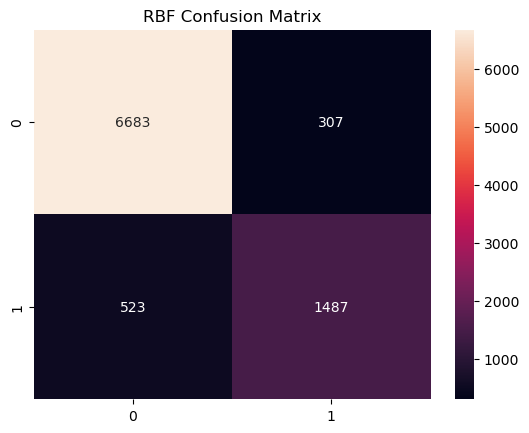

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6990
           1       0.83      0.74      0.78      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000



In [30]:
cm_rbf = confusion_matrix(y_test,rbf_pred)
print(cm_rbf)
sns.heatmap(cm_rbf,annot=True,fmt='d')
plt.title("RBF Confusion Matrix")
plt.show()
print(classification_report(y_test,rbf_pred))

In [31]:
bp_model = MLPClassifier(

    hidden_layer_sizes=(50,25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42

)

bp_model.fit(X_train,y_train)

,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [32]:
bp_pred = bp_model.predict(X_test)
bp_accuracy = accuracy_score(y_test,bp_pred)
print("BP Accuracy :",bp_accuracy)

BP Accuracy : 0.9063333333333333


[[6678  312]
 [ 531 1479]]


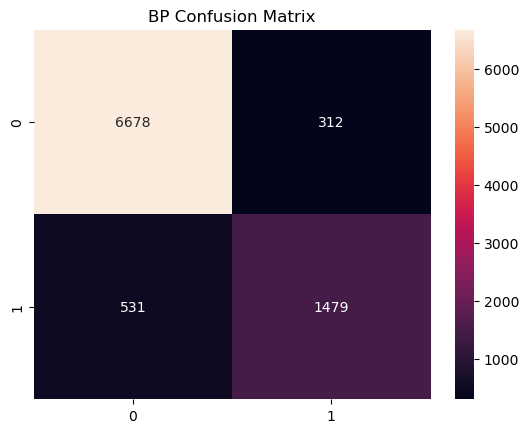

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6990
           1       0.83      0.74      0.78      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.90      0.91      0.90      9000



In [34]:
cm_bp = confusion_matrix(y_test,bp_pred)
print(cm_bp)
sns.heatmap(
    cm_bp,
    annot=True,
    fmt='d'
)

plt.title("BP Confusion Matrix")
plt.show()
print(classification_report(y_test,bp_pred))